<a href="https://colab.research.google.com/github/VioletteGL/Interpretabiidad-y-Causalidad-Bourbaki/blob/main/DoWhy_Tutorial_Completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial DoWhy

**Curso:** Interpretabilidad y Causalidad en Machine Learning (I_C2026)

Notebook para correr en Google Colab.
**Contenido**

1. ¿Qué es un problema causal?
2. Correlación no es causalidad
3. Grafos causales (DAGs) y sus tres patrones básicos
4. D-separación: cómo "leer" independencias en un dibujo
5. El operador $do$: de la intuición a la definición formal (SCM)
6. Las tres reglas del *do-calculus* de Pearl
7. Los 4 pasos de DoWhy
8. Ejemplo 1 — Confusor clásico (backdoor)
9. Ejemplo 2 — Mediador (por qué no siempre hay que controlar)
10. Ejemplo 3 — Collider (por qué controlar de más puede ser peor)
11. Tabla resumen de errores comunes
12. Ejercicios
13. Referencias


In [1]:
# Instalación (correr una sola vez por sesión de Colab)
!pip install -q dowhy graphviz networkx statsmodels

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import statsmodels.api as sm

import dowhy
from dowhy import CausalModel
from IPython.display import Image, display

np.random.seed(42)
print("Todo instalado. Versión de DoWhy:", dowhy.__version__)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.9/245.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 35.5 MB/s eta 0:00:00
Todo instalado. Versión de DoWhy: 0.14


## 1. ¿Qué es un problema causal?

Imagina que una escuela nota que los alumnos que llevan tutorías particulares sacan mejores calificaciones. La pregunta que le interesa a la escuela **no** es "¿los alumnos con tutor sacan mejor nota?" (eso ya lo sabemos, es un hecho de los datos). La pregunta real es:

> **Si tomara a un alumno cualquiera y lo obligara a tener tutor, ¿mejoraría su calificación?**

Esa segunda pregunta es *causal*: habla de una acción hipotética ("obligar a tener tutor"), no de un patrón que ya existe en los datos.

La primera se responde con estadística descriptiva; la segunda no, y ahí es donde entra el estudio causal.

El problema es que los alumnos que **ya** tienen tutor probablemente son distintos de los que no lo tienen desde antes: quizás sus papás tienen más recursos, o el alumno ya era más disciplinado. Esa diferencia previa puede ser la verdadera razón de la mejor calificación, no el tutor en sí. A esa "diferencia previa que contamina la comparación" se le llama **confusión**, y es el principal obstáculo de la inferencia causal.


## 2. Correlación no es causalidad

Simularemos una situación donde el verdadero efecto del tutor es *cero* **bold text** — el tutor no ayuda en nada — pero por culpa de un factor oculto (la disciplina del alumno), en los datos **parece** que tener tutor sí ayuda.


In [2]:
n = 3000

# "Disciplina" del alumno: un factor que no medimos directamente en este ejemplo
disciplina = np.random.normal(0, 1, n)

# La disciplina hace más probable que el alumno tenga tutor.
prob_tutor = 1 / (1 + np.exp(-disciplina))      # función logística
tiene_tutor = np.random.binomial(1, prob_tutor)

# ... y la disciplina TAMBIÉN mejora la calificación directamente.
# OJO: aquí el tutor NO tiene ningún efecto real sobre la calificación (coeficiente = 0)
calificacion = 70 + 15*disciplina + 0*tiene_tutor + np.random.normal(0, 5, n)

df_escuela = pd.DataFrame({
    "disciplina": disciplina,
    "tiene_tutor": tiene_tutor,
    "calificacion": calificacion
})

promedio_con_tutor = df_escuela.loc[df_escuela.tiene_tutor == 1, "calificacion"].mean()
promedio_sin_tutor = df_escuela.loc[df_escuela.tiene_tutor == 0, "calificacion"].mean()

print(f"Promedio CON tutor: {promedio_con_tutor:.1f}")
print(f"Promedio SIN tutor: {promedio_sin_tutor:.1f}")
print(f"Diferencia observada: {promedio_con_tutor - promedio_sin_tutor:.1f} puntos")
print("\n¡Parece que el tutor ayuda mucho! Pero en la simulación el efecto real es 0.")


Promedio CON tutor: 76.3
Promedio SIN tutor: 64.4
Diferencia observada: 11.9 puntos

¡Parece que el tutor ayuda mucho! Pero en la simulación el efecto real es 0.


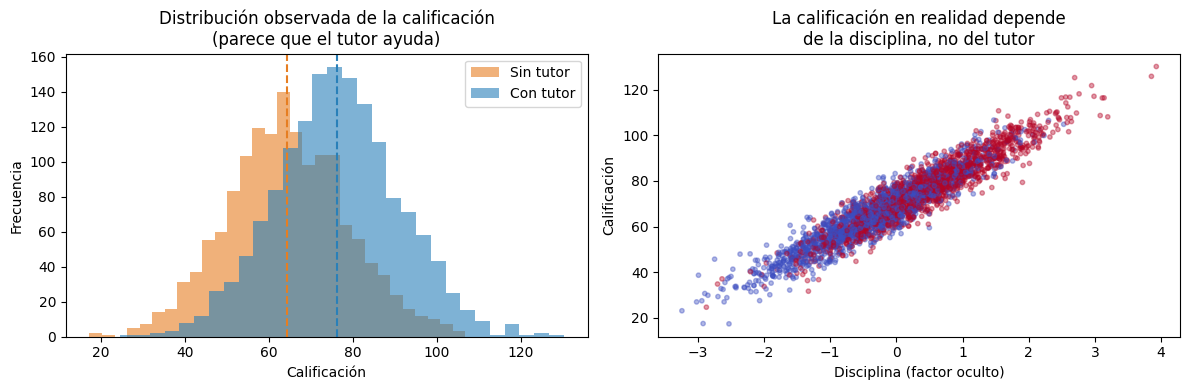

In [3]:
# Visualización: distribución de la calificación según si tuvo tutor o no
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_escuela.loc[df_escuela.tiene_tutor==0, "calificacion"], bins=30, alpha=0.6,
             label="Sin tutor", color="#e67e22")
axes[0].hist(df_escuela.loc[df_escuela.tiene_tutor==1, "calificacion"], bins=30, alpha=0.6,
             label="Con tutor", color="#2980b9")
axes[0].axvline(promedio_sin_tutor, color="#e67e22", linestyle="--")
axes[0].axvline(promedio_con_tutor, color="#2980b9", linestyle="--")
axes[0].set_xlabel("Calificación"); axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución observada de la calificación\n(parece que el tutor ayuda)")
axes[0].legend()

axes[1].scatter(df_escuela["disciplina"], df_escuela["calificacion"],
                 c=df_escuela["tiene_tutor"], cmap="coolwarm", alpha=0.4, s=10)
axes[1].set_xlabel("Disciplina (factor oculto)"); axes[1].set_ylabel("Calificación")
axes[1].set_title("La calificación en realidad depende\nde la disciplina, no del tutor")

plt.tight_layout()
plt.show()


En el panel derecho se ve la verdadera estructura: la calificación sube con la disciplina (eje X), sin importar el color (si tuvo tutor o no). La diferencia de promedios del panel izquierdo es un espejismo causado por la disciplina. Necesitamos una forma **sistemática** de distinguir un caso como este de un efecto causal real — para eso sirven los grafos causales.


## 3. Grafos causales (DAGs)

Un **DAG** (*Directed Acyclic Graph*) es un dibujo con:

- **Nodos** = variables
- **Flechas** = "esto causa aquello" (va de causa a efecto)
- **Acíclico** = nunca puedes seguir flechas y volver al punto de partida

Para el ejemplo de la escuela, el DAG es:

```
Disciplina ---> Tiene_tutor
    |                |
    |                v
    +----------> Calificación
```

A `Disciplina` (una variable que apunta hacia las otras dos) se le llama **confusor**: crea una asociación falsa entre tutor y calificación.

Hay tres patrones básicos de tres nodos que hay que reconocer siempre: Cadena, bifurcación y collider.

* Cadena:  $X \to M \to Y$, M es mediador,  $X$ afecta a $Y$ *a través de* $M$.
* Bifurcación:  $X \leftarrow Z \to Y$, Z es un Confusor.  $Z$ crea una asociación falsa entre $X$ y $Y$.
* Colisión:  $X \to C \leftarrow Y$, C es un Collider. $C$ es un efecto común; **no** hay confusión aquí.

Estos tres patrones se comportan de manera **opuesta** cuando "controlamos" (condicionamos) la variable de en medio, y esa diferencia es justo lo que resume la d-separación.


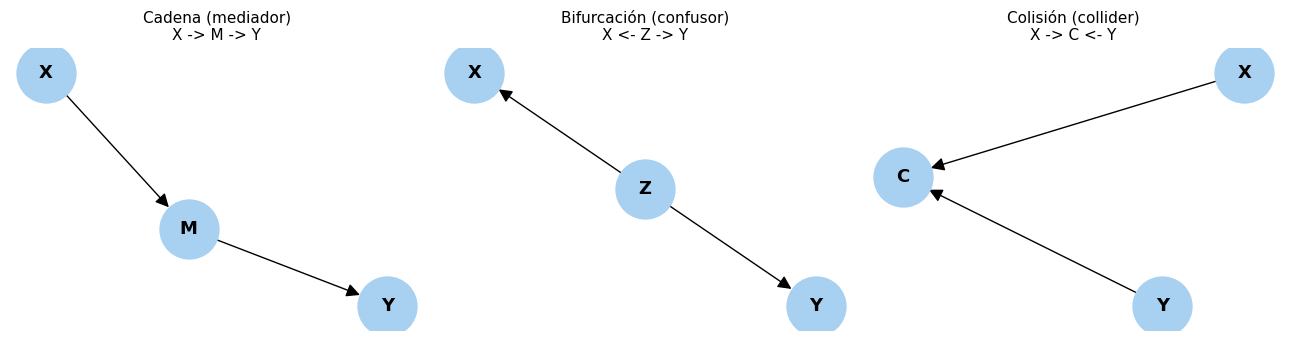

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
patrones = [
    ("Cadena (mediador)\nX -> M -> Y", [("X","M"),("M","Y")]),
    ("Bifurcación (confusor)\nX <- Z -> Y", [("Z","X"),("Z","Y")]),
    ("Colisión (collider)\nX -> C <- Y", [("X","C"),("Y","C")]),
]

for ax, (titulo, aristas) in zip(axes, patrones):
    G = nx.DiGraph()
    G.add_edges_from(aristas)
    pos = nx.spring_layout(G, seed=1)
    nx.draw(G, pos, ax=ax, with_labels=True, node_color="#a8d0f0",
            node_size=1800, font_size=13, font_weight="bold", arrowsize=20)
    ax.set_title(titulo, fontsize=11)

plt.tight_layout()
plt.show()


## 4. D-separación: cómo "leer" independencias en el dibujo

La **d-separación** es una regla visual para responder: *"dado este DAG, ¿son $X$ y $Y$ independientes si controlo (observo) tal conjunto de variables $W$?"*

Un **camino** entre $X$ y $Y$ está **bloqueado** dado $W$ si:

1. El camino contiene una **cadena** $A \to B \to C$ o una **bifurcación** $A \leftarrow B \to C$, con $B \in W$ (lo estás controlando), **o**
2. El camino contiene un **collider** $A \to B \leftarrow C$, y ni $B$ ni ningún descendiente de $B$ está en $W$ (no lo estás controlando).

Si **todos** los caminos entre $X$ y $Y$ están $W$-bloqueados, $X$ y $Y$ están **d-separadas** dado $W$, lo cual implica independencia estadística en cualquier distribución compatible con el DAG.

**Regla resumida:**

- **Cadena**: controlar $M$ **bloquea** el camino.
- **Bifurcación**: controlar $Z$ **bloquea** el camino (por eso a los confusores **sí** hay que controlarlos).
- **Collider**: controlar $C$ **abre** un camino que antes estaba cerrado (por eso a los colliders **nunca** hay que controlarlos).

Vamos a comprobar estas tres reglas con simulaciones numéricas en las secciones 8-10.


## 5. El operador $do$: de la intuición a la definición formal

### 5.1 Observar vs. actuar

- $P(Y \mid X = x)$ — **observar**: mira nada más a los alumnos que, por la razón que sea, ya tienen tutor. No cambia nada en el mundo, solo filtra los datos existentes.
- $P(Y \mid do(X = x))$ — **actuar**: imagina que agarras a *todos* los alumnos y les asignas tutor por decreto, sin importar su disciplina previa. Es un experimento hipotético.



### 5.2 Definición formal vía Modelos Causales

Cada variable $V_i$ se genera mediante

$$V_i = f_i(\text{Pa}(V_i), U_i)$$

donde $\text{Pa}(V_i)$ son sus padres en el DAG y $U_i$ es ruido exógeno.

La operación $do(X=x)$ se define como **cirugía estructural**: reemplaza la ecuación $X = f_X(\text{Pa}(X), U_X)$ por la constante $X=x$, **eliminando todas las flechas que entran a $X$**, y deja el resto del sistema intacto. El nuevo modelo (llamado $M_x$) induce una nueva distribución conjunta, y

$$P(Y \mid do(X=x)) := P_{M_x}(Y)$$

En nuestro ejemplo de la escuela, $do(\text{tiene\_tutor})$ borra la flecha `Disciplina -> Tiene_tutor`, dejando `Disciplina -> Calificación` intacta. Con esa "cirugía" se entiende por qué observar y actuar difieren: al observar, la flecha sigue "filtrando" quién tiene tutor; al actuar, esa flecha desaparece.

**La gran pregunta que resuelve DoWhy:** dado un DAG, ¿se puede calcular $P(Y\mid do(X))$ usando *solamente* datos observacionales? El *do-calculus* responde exactamente eso.


## 5.3 El criterio de Backdoor



Imagina que quieres saber si $X$ causa $Y$, pero sospechas que hay otras variables "por atrás" (como la disciplina de un alumno) que influyen tanto en $X$ como en $Y$, y que están inflando o distorsionando la asociación que ves en los datos.

La pregunta práctica es: **¿qué variables tengo que controlar (poner como covariables en mi regresión, o usar para emparejar/ponderar) para que la asociación que me quede entre $X$ y $Y$ sea puramente el efecto causal, sin contaminación de esos "caminos traseros"?**

El criterio backdoor te da una receta gráfica —basada solo en el dibujo del DAG, sin ver los datos— para encontrar ese conjunto de variables:

1. Dibuja todos los caminos que conectan $X$ con $Y$ en el grafo, **sin importar la dirección de las flechas** (caminos "no dirigidos").
2. De esos caminos, identifica los que entran a $X$ por una flecha (es decir, empiezan con $X \leftarrow \cdots$) — a esos se les llama **caminos backdoor** ("puerta trasera"), porque son rutas de confusión que no pasan por el efecto causal directo de $X$.
3. Busca un conjunto de variables $Z$ que, si las controlas, **cierre todos esos caminos backdoor** (usando la lógica de d-separación: en una bifurcación, controlar la variable de en medio cierra el camino) — pero que **no incluya ningún descendiente de $X$** (para no bloquear por accidente parte del efecto real, como en el caso del mediador).

Si encuentras ese $Z$, entonces controlar por $Z$ (por ejemplo, con una regresión que incluya $Z$ como covariable) te da el efecto causal correcto.

### Formalización

Sea $G$ un DAG causal y $(X, Y)$ un par ordenado de variables (tratamiento, resultado). Un conjunto de variables $Z$ satisface el **criterio backdoor** relativo a $(X,Y)$ si:

$$\textbf{(i)}\quad \text{Ningún nodo de } Z \text{ es descendiente de } X$$
$$\textbf{(ii)}\quad Z \text{ bloquea (d-separa) todo camino entre } X \text{ y } Y \text{ que contenga una flecha apuntando hacia } X$$

Si $Z$ satisface el criterio backdoor, entonces $P(y\mid do(x))$ es identificable y está dado por la **fórmula de ajuste backdoor**:

$$P(y\mid do(x)) = \sum_z P(y\mid x, z)\, P(z)$$

(o con integral en vez de suma si $Z$ es continua). Esta fórmula es exactamente la que derivamos "a mano" en la sección de do-calculus del notebook, combinando la Regla 2 (que permite cambiar $do(x)$ por $x$ una vez que $Z$ bloquea el camino trasero) y la Regla 3 (que dice que intervenir en $Z$ da lo mismo que no hacerlo, porque $X$ no la afecta).

**Nota importante:** el criterio backdoor es *suficiente* pero no *necesario* — puede haber grafos donde el efecto sí es identificable pero ningún conjunto $Z$ cumple estrictamente estas dos condiciones (ahí es donde entran frontdoor, IV, o el algoritmo ID general).

## 5.4 Criterio Frontdoor


El frontdoor resuelve un problema distinto y más contraintuitivo: ¿qué pasa si **sí** hay un confusor entre $X$ y $Y$, pero ese confusor **no lo observamos** (no está en nuestros datos), así que no lo podemos usar como $Z$ en un ajuste backdoor?

A primera vista parecería que estás perdido — sin poder observar el confusor, no puedes cerrar el camino trasero. Pero Pearl mostró un caso especial donde sí puedes recuperar el efecto: cuando existe una variable **mediadora** $M$ que:

- transmite *todo* el efecto de $X$ sobre $Y$ (es decir, $X$ solo afecta a $Y$ a través de $M$, no hay una flecha directa $X\to Y$),
- y esa mediadora $M$, a su vez, **no está confundida** con $X$ (no comparte causas ocultas con $X$),
- y el único camino de confusión entre $M$ y $Y$ pasa **por $X$** (que sí observamos, así que lo podemos controlar).

La idea intuitiva es una especie de "relevo en dos etapas": primero mides limpiamente el efecto de $X$ sobre $M$ (esa parte no está confundida), luego mides limpiamente el efecto de $M$ sobre $Y$ controlando por $X$ (esa parte tampoco lo está), y combinas ambas piezas para reconstruir el efecto total de $X$ sobre $Y$ — sin haber necesitado observar jamás el confusor original.

### Formalización

Sea $G$ un DAG causal con posible confusión no observada entre $X$ y $Y$. Un conjunto de variables $M$ satisface el **criterio frontdoor** relativo a $(X,Y)$ si:

$$\textbf{(i)}\quad M \text{ intercepta todos los caminos dirigidos de } X \text{ a } Y \text{ (todo el efecto de } X \text{ sobre } Y \text{ pasa por } M\text{)}$$
$$\textbf{(ii)}\quad \text{No existe camino backdoor (no bloqueado) de } X \text{ a } M$$
$$\textbf{(iii)}\quad X \text{ bloquea todo camino backdoor de } M \text{ a } Y$$

Si $M$ satisface el criterio frontdoor, entonces $P(y\mid do(x))$ es identificable mediante la **fórmula frontdoor**:

$$P(y\mid do(x)) = \sum_m P(m\mid x) \sum_{x'} P(y\mid x', m)\, P(x')$$

Nota la estructura de "dos etapas": el término $P(m\mid x)$ es el efecto (limpio, por la condición ii) de $X$ sobre $M$; el término $\sum_{x'} P(y\mid x',m)P(x')$ es el efecto backdoor-ajustado (limpio, por la condición iii, usando $X$ como la variable de ajuste) de $M$ sobre $Y$.

**Conexión con las tres reglas:** a diferencia del backdoor (que usa solo la Regla 2), la derivación completa del frontdoor combina las **tres reglas del do-calculus** — es un buen ejercicio para los estudiantes más avanzados derivarla paso a paso, análogo a como se hizo con el backdoor.

**Ejemplo clásico de Pearl:** fumar ($X$) → alquitrán en los pulmones ($M$) → cáncer ($Y$), con un gen confusor no observado que afecta a fumar y (directamente, hipotéticamente) a cáncer, pero no al alquitrán.

## 6. Las tres reglas del *do-calculus* (Juea Pearl, 1995)

Sea $G$ el DAG causal, y $G_{\overline{X}}$ / $G_{\underline{X}}$ el grafo con las flechas que entran/salen de $X$ eliminadas. Para conjuntos disjuntos de variables $X, Y, Z, W$:



**1. Inserción/eliminación de observaciones**
$$P(y \mid do(x), z, w) = P(y \mid do(x), w) \quad \text{si } (Y \perp Z \mid X, W)_{G_{\overline{X}}}$$
*Intuición:* si en el grafo mutilado (quitando flechas hacia $X$) $Z$ queda d-separada de $Y$, observar $Z$ no aporta información extra.

**2. Intercambio acción/observación (justifica el criterio backdoor)**
$$P(y \mid do(x), do(z), w) = P(y \mid do(x), z, w) \quad \text{si } (Y \perp Z \mid X, W)_{G_{\overline{X}}\underline{Z}}$$
*Intuición:* si $Z$ no tiene caminos backdoor abiertos hacia $Y$ (dado lo que ya controlamos), da lo mismo intervenir sobre $Z$ que observarla. Esta regla formaliza el ajuste por confusores (bifurcaciones) de la Sección 4.

**3.  Inserción/eliminación de acciones**
$$P(y \mid do(x), do(z), w) = P(y \mid do(x), w) \quad \text{si } (Y \perp Z \mid X, W)_{G_{\overline{X}}\overline{Z(W)}}$$
*Intuición:* si intervenir sobre $Z$ no tiene ningún camino causal hacia $Y$, esa intervención es irrelevante y se puede "olvidar".

**INTUICIÓN CLAVE:** $P(Y\mid do(X))$ es identificable si y solo si existe una secuencia de aplicaciones de estas tres reglas que la reduzca a una expresión puramente observacional. DoWhy usa directamente el **criterio backdoor** (caso particular de la Regla 2) para el caso de ajuste por confusores, y también soporta identificación vía **variables instrumentales** y **criterio frontdoor** (que combina las tres reglas).


# 6.1 Derivación paso a paso: el caso backdoor simple

Grafo: $Z \to X \to Y$, $Z \to Y$ (nuestro confusor clásico, con $Z=$disciplina).

 Queremos $P(y \mid do(x))$.

$$P(y\mid do(x)) = \sum_z P(y\mid do(x), z)\, P(z \mid do(x))$$

Aplicando **Regla 3** sobre $P(z\mid do(x))$: como $Z$ no es descendiente de $X$, intervenir en $X$ no cambia la distribución de $Z$, entonces $P(z\mid do(x)) = P(z)$.

Aplicando **Regla 2** sobre $P(y\mid do(x), z)$: $Z$ satisface el criterio backdoor respecto a $(X,Y)$ (bloquea el único camino backdoor $X \leftarrow Z \to Y$), así que podemos cambiar la intervención por observación: $P(y\mid do(x), z) = P(y \mid x, z)$.

Entonces:
$$P(y\mid do(x)) = \sum_z P(y\mid x, z)\, P(z) \qquad \text{(fórmula de ajuste backdoor)}$$

Esto es exactamente lo que verás como el "estimando" (*estimand*) que DoWhy imprime en el paso de identificación.


## 7. Los 4 pasos de DoWhy

| Paso | Pregunta que responde | Qué hace |
|---|---|---|
| **Model** | ¿Cuáles son mis supuestos causales? | Construyes el DAG |
| **Identify** | ¿$P(Y\mid do(X))$ es expresable sin *do*? | Aplica do-calculus (backdoor / IV / frontdoor) y devuelve el estimando |
| **Estimate** | ¿Cuál es el valor numérico del estimando? | Usa tus datos con el método que elijas |
| **Refute** | ¿Qué tan robusta es mi estimación? | Pruebas de sensibilidad |

**Identify** es puramente gráfico (do-calculus sobre el DAG, no toca los datos). **Estimate** es puramente estadístico (usa los datos, dado el estimando).


## 8. Ejemplo 1 — Confusor clásico (backdoor)

Retomamos el ejemplo de la escuela (`disciplina -> tiene_tutor -> calificacion`, con `disciplina -> calificacion` también) y lo resolvemos completo con DoWhy.


In [5]:
modelo_ingenuo = sm.OLS(df_escuela["calificacion"], sm.add_constant(df_escuela["tiene_tutor"])).fit()
print("Coeficiente de una regresión ingenua calificacion ~ tiene_tutor (sin controlar disciplina):")
print(f"  beta_hat = {modelo_ingenuo.params['tiene_tutor']:.3f}   (verdadero = 0)")
print("-> sesgado, tal como vimos en la Sección 2.")


Coeficiente de una regresión ingenua calificacion ~ tiene_tutor (sin controlar disciplina):
  beta_hat = 11.910   (verdadero = 0)
-> sesgado, tal como vimos en la Sección 2.


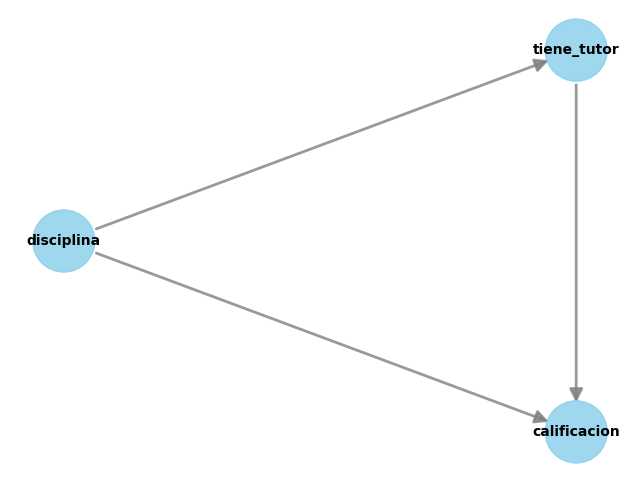

In [17]:
# Paso 1: MODEL
modelo1 = CausalModel(
    data=df_escuela,
    treatment="tiene_tutor",
    outcome="calificacion",
    common_causes=["disciplina"]
)

modelo1.view_model()
#display(Image(filename="causal_model.png"))


In [7]:
# Paso 2: IDENTIFY -- aquí actúa el do-calculus
estimando1 = modelo1.identify_effect(proceed_when_unidentifiable=True)
print(estimando1)


Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
      d                                  
─────────────(E[calificacion|disciplina])
d[tieneₜᵤₜₒᵣ]                            
Estimand assumption 1, Unconfoundedness: If U→{tiene_tutor} and U→calificacion then P(calificacion|tiene_tutor,disciplina,U) = P(calificacion|tiene_tutor,disciplina)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
      d                                  
─────────────(E[calificacion|disciplina])
d[tieneₜᵤₜₒᵣ]                            
Estimand assumption 1, Unconfoundedness: If U→{tiene_tutor} and U→calificacion then P(calificacion|tiene_tutor,disciplina,U) = P(calificacion|tiene_tutor,disciplina)



DoWhy imprime el estimando backdoor: controlar por `disciplina`.

Es exactamente la fórmula $\sum_z P(y\mid x,z)P(z)$ derivada a mano en la Sección 6 usando las Reglas 2 y 3.


* `Estimand type` — qué tipo de efecto se está identificando. NONPARAMETRIC_ATE significa efecto promedio del tratamiento (Average Treatment Effect), sin asumir ninguna forma funcional (ni linealidad ni nada)

* `Estimand : N` — DoWhy no te da un solo estimando: busca todas las estrategias de identificación que apliquen (backdoor, IV, frontdoor) y te las muestra todas. Tú luego eliges cuál usar en estimate_effect(method_name=...)

* `Estimand expression` — la fórmula matemática del estimando, escrita en notación de derivada:

Esta notación con derivada es la generalización continua de la fórmula backdoor discreta que vimos,
$ \sum P(y∣x,z)P(z)$ : para tratamiento continuo (o para leer el efecto marginal), DoWhy expresa el estimando como la derivada de la esperanza condicional respecto al tratamiento, ya promediada sobre la distribución de las variables de ajuste. Si ves Sum(...) o Integral(...) en vez de Derivative(...), es la misma fórmula pero escrita explícitamente como suma/integral en vez de derivada — DoWhy elige la notación según el tipo de estimando.

* `Estimand assumption`: Es decir: "cualquier confusor no observado
$U$ que pudiera existir, una vez que controlo por $Z$ (`disciplina`), deja de importar".

Esto es exactamente el supuesto de ignorabilidad condicional / unconfoundedness que ya conoces — DoWhy te lo está recordando explícitamente cada vez, precisamente porque es un supuesto que no se puede verificar con los datos, solo se puede argumentar con conocimiento del dominio (por eso el paso `refute_estimate` existe: no prueba el supuesto, pero puede delatar cuando es claramente falso).


* `No such variable(s) found!` — significa que ese criterio específico no aplica a este grafo (por ejemplo, no hay ninguna variable que satisfaga las tres condiciones del frontdoor). Esto es información útil, no un error: te confirma que backdoor es tu única vía en este caso.



In [8]:
# Paso 3: ESTIMATE
estimacion1 = modelo1.estimate_effect(estimando1, method_name="backdoor.linear_regression")
print(estimacion1)
print(f"\nEfecto estimado del tutor: {estimacion1.value:.3f}  (verdadero: 0)")


*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
      d                                  
─────────────(E[calificacion|disciplina])
d[tieneₜᵤₜₒᵣ]                            
Estimand assumption 1, Unconfoundedness: If U→{tiene_tutor} and U→calificacion then P(calificacion|tiene_tutor,disciplina,U) = P(calificacion|tiene_tutor,disciplina)

## Realized estimand
b: calificacion~tiene_tutor+disciplina
Target units: ate

## Estimate
Mean value: -0.46863844551499767


Efecto estimado del tutor: -0.469  (verdadero: 0)


In [9]:
# Paso 4: REFUTE
refutacion1a = modelo1.refute_estimate(estimando1, estimacion1, method_name="random_common_cause")
print(refutacion1a)

refutacion1b = modelo1.refute_estimate(estimando1, estimacion1, method_name="placebo_treatment_refuter",
                                        placebo_type="permute")
print(refutacion1b)


Refute: Add a random common cause
Estimated effect:-0.46863844551499767
New effect:-0.4688511015831729
p value:0.84

Refute: Use a Placebo Treatment
Estimated effect:-0.46863844551499767
New effect:-0.01685797968405012
p value:0.88



**Cómo leer las refutaciones:**
* `random_common_cause` agrega un confusor inventado — el efecto debería casi no cambiar.
*  `placebo_treatment_refuter` reemplaza el tratamiento por ruido — el efecto debería colapsar a ~0.

 Ninguna prueba *demuestra* que el DAG es correcto, pero sí puede delatar errores de especificación.


## 9. Ejemplo 2 — Mediador (por qué no siempre hay que controlar)

Ahora sí le damos al tutor un efecto real, pero **a través de** un mediador: `tiene_tutor -> horas_estudio -> calificacion`. Si controláramos por `horas_estudio` (el mediador), bloquearíamos parte del efecto real del tutor — como anticipa la regla de "cadena" de la Sección 4.


In [10]:
n = 4000
tutor2 = np.random.binomial(1, 0.5, n)
horas_estudio = 3 + 4*tutor2 + np.random.normal(0, 1, n)          # mediador: depende del tutor
efecto_directo = 1.0
efecto_indirecto_via_horas = 4 * 2.5
calificacion2 = 60 + efecto_directo*tutor2 + 2.5*horas_estudio + np.random.normal(0, 3, n)

df_mediador = pd.DataFrame({"tutor": tutor2, "horas_estudio": horas_estudio, "calificacion": calificacion2})
efecto_total_verdadero = efecto_directo + efecto_indirecto_via_horas
print(f"Efecto TOTAL verdadero del tutor: {efecto_total_verdadero:.2f}")
print(f"  (directo = {efecto_directo}, indirecto vía horas de estudio = {efecto_indirecto_via_horas:.2f})")


Efecto TOTAL verdadero del tutor: 11.00
  (directo = 1.0, indirecto vía horas de estudio = 10.00)


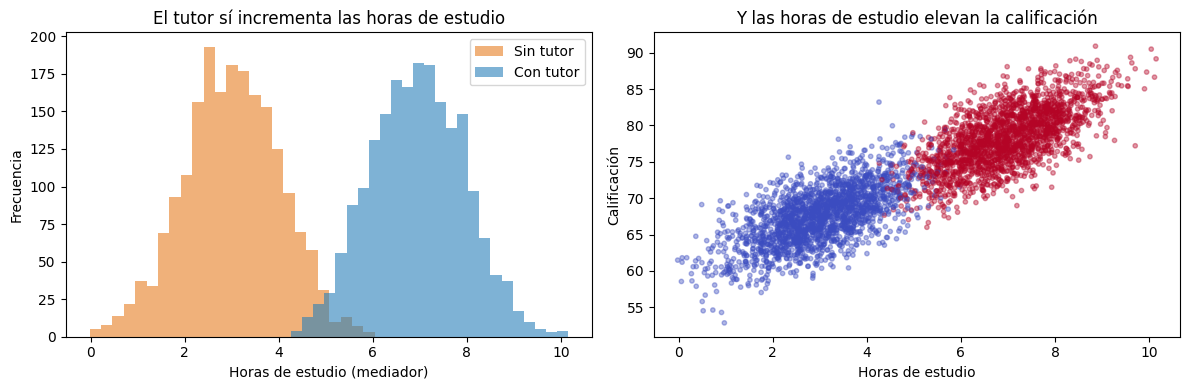

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_mediador.loc[df_mediador.tutor==0, "horas_estudio"], bins=25, alpha=0.6,
             label="Sin tutor", color="#e67e22")
axes[0].hist(df_mediador.loc[df_mediador.tutor==1, "horas_estudio"], bins=25, alpha=0.6,
             label="Con tutor", color="#2980b9")
axes[0].set_xlabel("Horas de estudio (mediador)"); axes[0].set_ylabel("Frecuencia")
axes[0].set_title("El tutor sí incrementa las horas de estudio")
axes[0].legend()

axes[1].scatter(df_mediador["horas_estudio"], df_mediador["calificacion"],
                 c=df_mediador["tutor"], cmap="coolwarm", alpha=0.4, s=10)
axes[1].set_xlabel("Horas de estudio"); axes[1].set_ylabel("Calificación")
axes[1].set_title("Y las horas de estudio elevan la calificación")

plt.tight_layout()
plt.show()


ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...


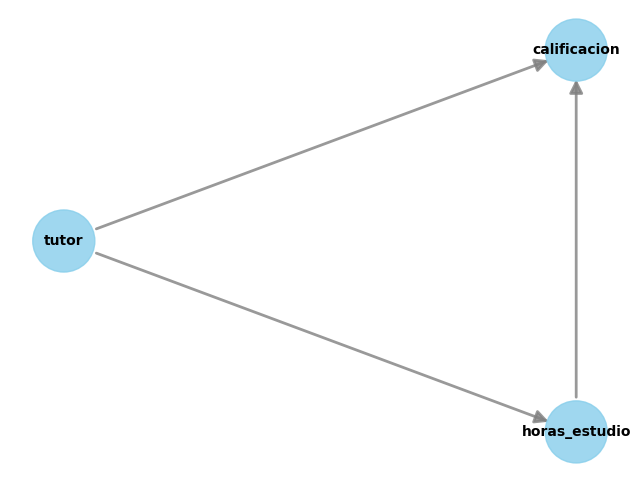

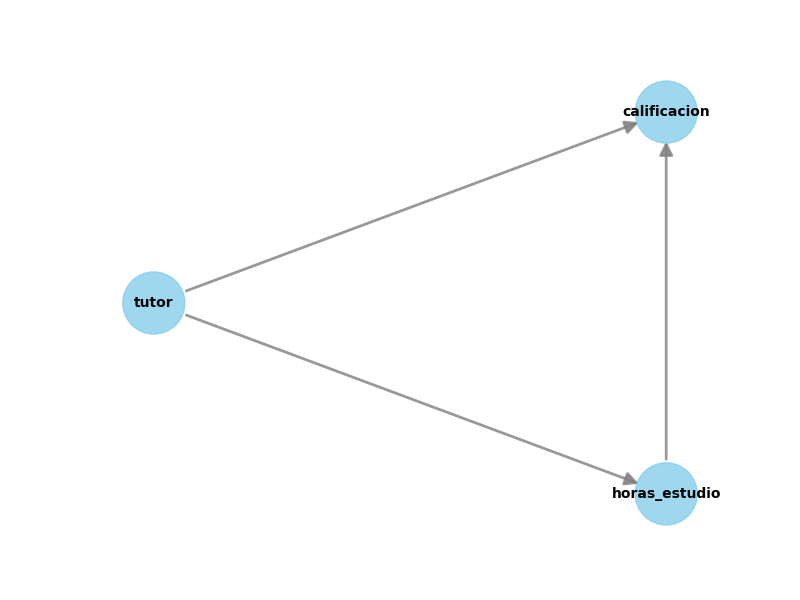

In [12]:
# Grafo: tutor -> horas_estudio -> calificacion, tutor -> calificacion (efecto directo)
modelo2 = CausalModel(
    data=df_mediador,
    treatment="tutor",
    outcome="calificacion",
    graph="digraph{tutor->horas_estudio; horas_estudio->calificacion; tutor->calificacion;}"
)
modelo2.view_model()
#display(Image(filename="causal_model.png"))


In [13]:
estimando2 = modelo2.identify_effect(proceed_when_unidentifiable=True)
estimacion2_correcta = modelo2.estimate_effect(estimando2, method_name="backdoor.linear_regression")
print("Efecto TOTAL (correcto, sin condicionar en horas_estudio):", round(estimacion2_correcta.value, 3))

# Qué pasa si, por error, controlamos también por el mediador
modelo_erroneo = sm.OLS(df_mediador["calificacion"],
                         sm.add_constant(df_mediador[["tutor", "horas_estudio"]])).fit()
print("Efecto si controlas por el mediador por error (solo mide el directo):",
      round(modelo_erroneo.params["tutor"], 3))


Efecto TOTAL (correcto, sin condicionar en horas_estudio): 10.704
Efecto si controlas por el mediador por error (solo mide el directo): 0.554


El modelo correcto (sin controlar por `horas_estudio`) recupera el efecto **total** ($\approx 11$); controlar por el mediador solo recupera el efecto **directo** ($\approx 1$), porque condicionar en `horas_estudio` cierra el camino `tutor -> horas_estudio -> calificacion`. DoWhy, al construir el estimando desde el grafo declarado, reconoce automáticamente que `horas_estudio` es descendiente del tratamiento y no lo usa como ajuste.


## 10. Ejemplo 3 — Collider (por qué controlar de más puede ser peor)

Este es el error más contraintuitivo: controlar por una variable que es un **efecto común** de $X$ y $Y$ (un collider) crea una correlación falsa donde antes no había ninguna. Simulamos `talento` y `esfuerzo`, dos variables **independientes** entre sí, que ambas determinan si un alumno recibe una `beca`.


In [14]:
n = 3000
talento = np.random.normal(0, 1, n)
esfuerzo = np.random.normal(0, 1, n)                 # independiente de talento, por construcción
beca = ((talento + esfuerzo) > 1).astype(int)         # COLLIDER: efecto común de ambas

df_collider = pd.DataFrame({"talento": talento, "esfuerzo": esfuerzo, "beca": beca})

corr_completa = df_collider["talento"].corr(df_collider["esfuerzo"])
corr_becados = df_collider.loc[df_collider.beca == 1, "talento"].corr(
                 df_collider.loc[df_collider.beca == 1, "esfuerzo"])

print(f"Correlación talento-esfuerzo en TODOS los alumnos: {corr_completa:.3f}  (cercana a 0)")
print(f"Correlación talento-esfuerzo SOLO entre becados:   {corr_becados:.3f}  (¡correlación negativa falsa!)")


Correlación talento-esfuerzo en TODOS los alumnos: -0.008  (cercana a 0)
Correlación talento-esfuerzo SOLO entre becados:   -0.573  (¡correlación negativa falsa!)


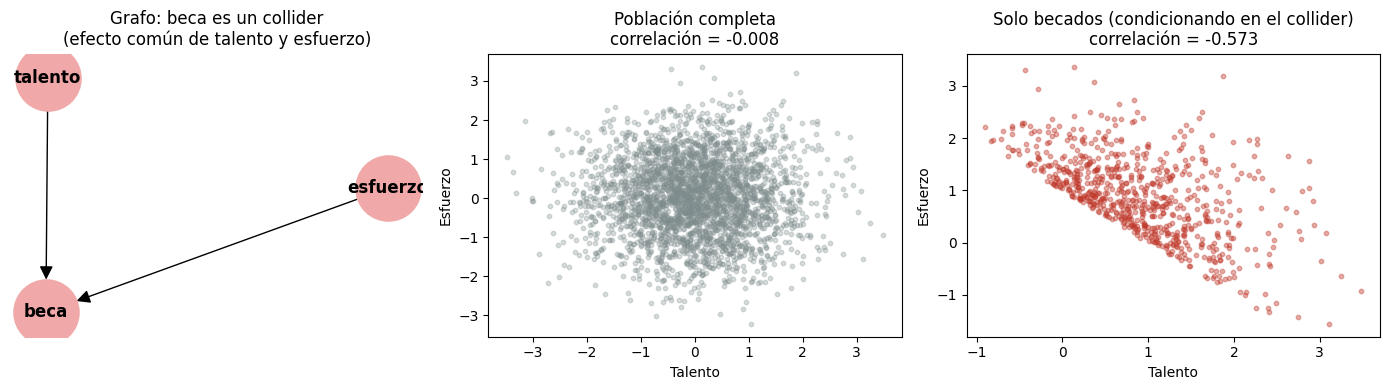

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

G = nx.DiGraph()
G.add_edges_from([("talento","beca"), ("esfuerzo","beca")])
pos = nx.spring_layout(G, seed=3)
nx.draw(G, pos, ax=axes[0], with_labels=True, node_color="#f0a8a8",
        node_size=2200, font_size=12, font_weight="bold", arrowsize=20)
axes[0].set_title("Grafo: beca es un collider\n(efecto común de talento y esfuerzo)")

axes[1].scatter(df_collider["talento"], df_collider["esfuerzo"], alpha=0.3, s=10, color="#7f8c8d")
axes[1].set_xlabel("Talento"); axes[1].set_ylabel("Esfuerzo")
axes[1].set_title(f"Población completa\ncorrelación = {corr_completa:.3f}")

sub = df_collider[df_collider.beca == 1]
axes[2].scatter(sub["talento"], sub["esfuerzo"], alpha=0.4, s=10, color="#c0392b")
axes[2].set_xlabel("Talento"); axes[2].set_ylabel("Esfuerzo")
axes[2].set_title(f"Solo becados (condicionando en el collider)\ncorrelación = {corr_becados:.3f}")

plt.tight_layout()
plt.show()


En el panel derecho, entre los becados, un talento bajo "obliga" a que el esfuerzo haya sido alto (si no, no habrían calificado para la beca), y viceversa — de ahí la correlación negativa artificial. A esto se le llama **sesgo de collider** o **paradoja de Berkson**, y ocurre únicamente porque filtramos (condicionamos) por el collider `beca`, tal como predice la regla de d-separación de la Sección 4.

Si le pidieras a DoWhy identificar el efecto de `talento` sobre `esfuerzo` con `beca` declarada por error como `common_cause`, el estimando resultante estaría sesgado — por eso el paso de **Model** (donde tú declaras el DAG) es tan importante: DoWhy no puede adivinar por ti si una variable es confusor, mediador o collider.


## 11. Tabla resumen de errores comunes

| Patrón | Ejemplo | ¿Controlar por la variable de en medio? | Consecuencia de controlar |
|---|---|---|---|
| Bifurcación (confusor) | `disciplina` en el Ejemplo 1 | **Sí** | Elimina el sesgo de confusión |
| Cadena (mediador) | `horas_estudio` en el Ejemplo 2 | **No**, si quieres el efecto total | Subestima el efecto (bloquea un camino real) |
| Colisión (collider) | `beca` en el Ejemplo 3 | **Nunca** | Crea una correlación falsa (paradoja de Berkson) |

La forma de no equivocarte es siempre la misma: **dibuja el DAG primero**, y deja que la d-separación (o, en casos más complejos, las tres reglas del do-calculus) te diga qué conjunto de variables es válido para el ajuste.


## 12. Ejercicios propuestos

1. En el Ejemplo 1, agrega un segundo confusor `recursos_familiares` (correlacionado con `disciplina`) y verifica que `identify_effect` lo incluya automáticamente al declararlo en `common_causes`.
2. En el Ejemplo 2, corre `identify_effect` sobre el grafo **sin** la flecha `tutor->calificacion` directa (es decir, el tutor solo actúa a través de las horas de estudio) y compara el estimando con el caso actual.
3. Construye un grafo con **criterio frontdoor**: `X -> M -> Y` con un confusor no observado entre $X$ y $Y$ (pero $M$ no confundido). Usa `method_name="frontdoor.two_stage_regression"` y compara con la fórmula de frontdoor de Pearl.
4. Agrega una variable instrumental $I$ que afecte a `tiene_tutor` pero no tenga efecto directo sobre `calificacion` ni comparta confusores con ella. Verifica que DoWhy también reporte el estimando IV como alternativa.
5. Corre `method_name="data_subset_refuter"` sobre el Ejemplo 1 y comenta si el efecto estimado es estable al usar distintos subconjuntos de los datos.
6. Sin usar DoWhy: identifica el patrón (cadena, bifurcación o colisión) en cada situación, y decide si controlarías por la variable de en medio:
   - Fiebre → Sudoración, Fiebre → Dolor de cabeza
   - Ejercicio → Buena condición física → Longevidad
   - Ser aceptado en una universidad de élite ← Buenas notas, Ser aceptado en una universidad de élite ← Buena entrevista


## 13. Referencias

- Pearl, J., Glymour, M. & Jewell, N. (2016). *Causal Inference in Statistics: A Primer*.
- Pearl, J. (1995). *Causal diagrams for empirical research*. Biometrika.
- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference* (2nd ed.), Capítulo 3 (do-calculus).
- Sharma, A. & Kiciman, E. (2020). *DoWhy: An End-to-End Library for Causal Inference*. [arXiv:2011.04216](https://arxiv.org/abs/2011.04216)
- Documentación oficial: [https://www.pywhy.org/dowhy/](https://www.pywhy.org/dowhy/)
